In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv
from statsmodels.stats.anova import AnovaRM

from multipred.data import compute_dprime
from multipred.plotting import barplot_morey, barplot_morey_maineffect

# Load and prepare data

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
ROI = "EVC"
n_voxels = "wholeROI"
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/{ROI}_{n_voxels}"
df = pd.read_csv(f"{DATA_PATH}/balanced_group_data.csv")

Columns for SDT  
For these analyses we will consider 2 things.  
1 - the type of decision:
> Hit: stimulus EXP and CORRECT decision  
> False alarm: UEX and incorrect  
> Correct rejection: UEX and acorrect  
> Miss: EXP and incorrect

2 - Evidence strength  
For this we will use the signed distance from the hyperplane at each decision


In [3]:
# New distance column
# In the decision_distances column, negative values correspond to CCW decisions and positive values to CW decisions
# For our purpose, these two decisions are equivalent. What we need to consider is wether the choice was expected or not
# To collapse the decisions based on expectation conditions, we will invert the sign of the distance when CCW was expected.
# This way, the distance will always be positive when the decision was expected and negative when it was unexpected

# Let's start by creating a new column with the expected stimulus. This should be equal to the column labels when pred == 1, and the opposite when pred == 0
df["expected_stim"] = np.where(
    df["v_pred"] == 1, 
    df["labels"], 
    np.where(df["labels"] == 45, 135, 45)
)

# Now we can calculate the new distance column. We will invert the sign when 135 was the expected stimulus
df["distance"] = np.where(df["expected_stim"] == 135, -df["decision_distances"], df["decision_distances"])

# Finally for each subject we z score the distances
# Z-normalize `distance` within each subject
df['z_distance'] = df.groupby('subj')['distance'].transform(
    lambda x: (x - x.mean()) / x.std())


# Decision types columns
# Hit column
df["hit"] = np.where(
    (df["correct"] == 1) & (df["v_pred"] == 1), 1, 0
)

df["fa"] = np.where(
    (df["correct"] == 0) & (df["v_pred"] == 0), 1, 0
)

df["CR"] = np.where(
    (df["correct"] == 1) & (df["v_pred"] == 0), 1, 0
)

df["miss"] = np.where(
    (df["correct"] == 0) & (df["v_pred"] == 1), 1, 0
)


# Alternatively, code decision type in a single column
df["decision_type"] = np.where(
    (df["correct"] == 1) & (df["v_pred"] == 1), "hit",
    np.where(
        (df["correct"] == 0) & (df["v_pred"] == 0), "fa",
        np.where(
            (df["correct"] == 1) & (df["v_pred"] == 0), "CR",
            np.where(
                (df["correct"] == 0) & (df["v_pred"] == 1), "miss",
                "error"
            )
        )
    )
)

# New column for signal and noise trials
df["signal_noise"] = np.where(
    (df["decision_type"] == "hit") | (df["decision_type"] == "miss"), "signal",
    np.where(
        (df["decision_type"] == "fa") | (df["decision_type"] == "CR"), "noise",
        "error"
    )
)

## Unimodal effects

In [4]:
# Compute visual d' and criterion for each subject by attention.
sdt_df =compute_dprime(df, "signal_noise", ["modality"])

# repeated measures ANOVA on d' and criterion
aov_dprime = AnovaRM(sdt_df, "d_prime", "subj", within=["modality"])
dprime_results = aov_dprime.fit()

aov_criterion = AnovaRM(sdt_df, "criterion", "subj", within=["modality"])
criterion_results = aov_criterion.fit()

# t-tests on d' and criterion
t_dprime = pg.pairwise_tests(data=sdt_df, dv="d_prime", within=["modality"], subject="subj", padjust="fdr_bh")
t_criterion = pg.pairwise_tests(data=sdt_df, dv="criterion", within=["modality"], subject="subj", padjust="fdr_bh")

C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


,F Value,Num DF,Den DF,Pr > F
modality,3.7143,1.0000,24.0000,0.0659


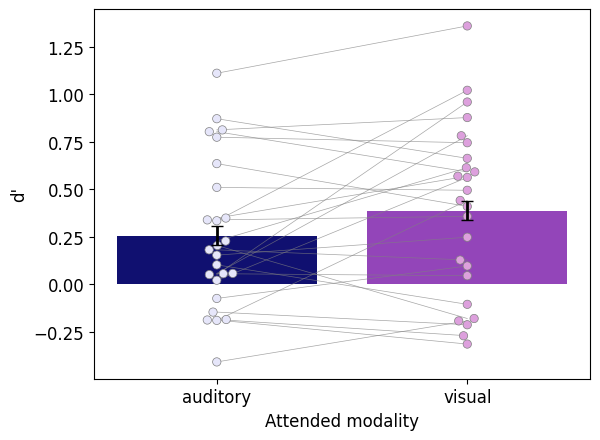

In [5]:
barplot_morey_maineffect(sdt_df, "modality", "d_prime", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel("d'")
plt.xlabel("Attended modality")
dprime_results.summary()

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


,F Value,Num DF,Den DF,Pr > F
modality,2.6746,1.0000,24.0000,0.1150


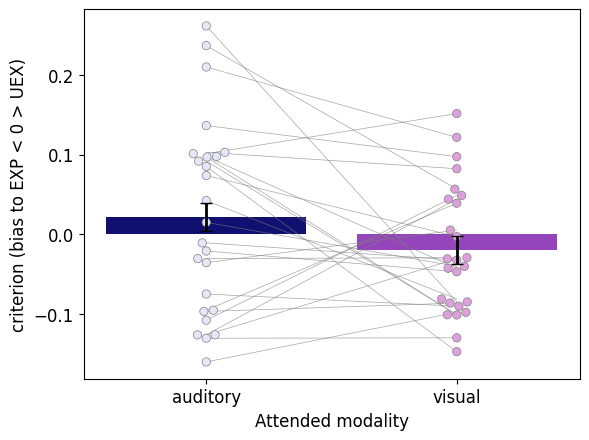

In [7]:
barplot_morey_maineffect(sdt_df, "modality", "criterion", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel("criterion (bias to EXP < 0 > UEX)")
plt.xlabel("Attended modality")
criterion_results.summary()

## Cross-modal effects

In [6]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
sdt_df =compute_dprime(df, "signal_noise", ["modality", "a_pred"])

# two-way repeated measures ANOVA on d' and criterion
aov_dprime = AnovaRM(sdt_df, "d_prime", "subj", within=["modality", "a_pred"])
dprime_results = aov_dprime.fit()

aov_criterion = AnovaRM(sdt_df, "criterion", "subj", within=["modality", "a_pred"])
criterion_results = aov_criterion.fit()

# t-tests on d' and criterion
t_dprime = pg.pairwise_tests(data=sdt_df, dv="d_prime", within=["modality", "a_pred"], subject="subj", padjust="fdr_bh")
t_criterion = pg.pairwise_tests(data=sdt_df, dv="criterion", within=["modality", "a_pred"], subject="subj", padjust="fdr_bh")

,F Value,Num DF,Den DF,Pr > F
modality,3.6913,1.0000,24.0000,0.0667
a_pred,0.4683,1.0000,24.0000,0.5003
modality:a_pred,2.9473,1.0000,24.0000,0.0989


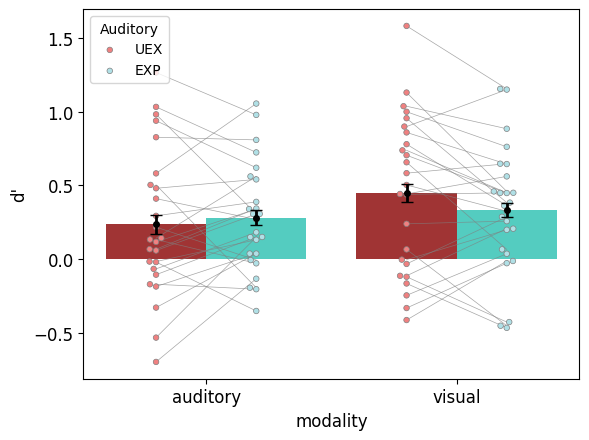

In [7]:
x = "modality"; y = "d_prime"; hue = "a_pred"
palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]

barplot_morey(sdt_df, x=x, y=y, hue=hue, hue_label="Auditory expected", palette1=palette1, palette2=palette2)
plt.ylabel("d'")

plt.legend(title="Auditory", loc="upper left", labels=["UEX", "EXP"])

#plt.savefig(f"figures/sdt/dprime_{ROI}.svg", dpi=300)
dprime_results.summary()

In [8]:
t_dprime

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.921273,24.0,two-sided,0.066651,NaN,NaN,1.023,-0.303661
1,a_pred,-,0,1,True,True,0.684291,24.0,two-sided,0.500347,NaN,NaN,0.261,0.083932
2,modality * a_pred,auditory,0,1,True,True,-0.602567,24.0,two-sided,0.552448,0.552448,fdr_bh,0.249,-0.097496
3,modality * a_pred,visual,0,1,True,True,1.733232,24.0,two-sided,0.095886,0.191772,fdr_bh,0.775,0.231075


,F Value,Num DF,Den DF,Pr > F
modality,2.6125,1.0000,24.0000,0.1191
a_pred,0.7712,1.0000,24.0000,0.3885
modality:a_pred,2.2620,1.0000,24.0000,0.1456


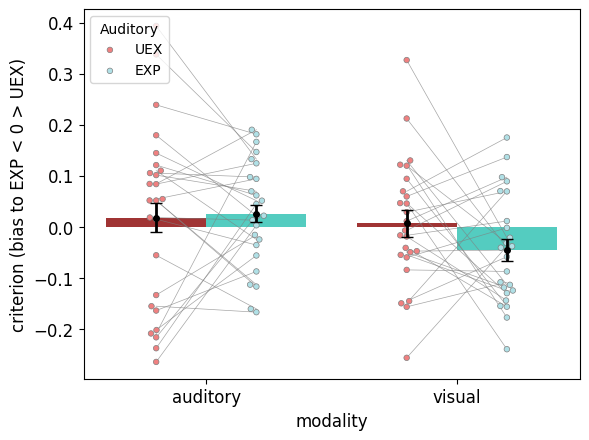

In [9]:
x = "modality"; y = "criterion"; hue = "a_pred"
palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]

barplot_morey(sdt_df, x=x, y=y, hue=hue, hue_label="Auditory", palette1=palette1, palette2=palette2)
plt.ylabel("criterion (bias to EXP < 0 > UEX)")

plt.legend(title="Auditory", loc="upper left", labels=["UEX", "EXP"])

#plt.savefig(f"figures/sdt/criterion_{ROI}.svg", dpi=300)
criterion_results.summary()

In [10]:
t_criterion

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,1.616309,24.0,two-sided,0.119098,NaN,NaN,0.659,0.390668
1,a_pred,-,0,1,True,True,0.878207,24.0,two-sided,0.388539,NaN,NaN,0.299,0.213629
2,modality * a_pred,auditory,0,1,True,True,-0.233232,24.0,two-sided,0.817559,0.817559,fdr_bh,0.216,-0.050990
3,modality * a_pred,visual,0,1,True,True,1.611734,24.0,two-sided,0.120094,0.240188,fdr_bh,0.655,0.448929


Visualize "signal" and "noise" distributions.

C:\Users\marcs\AppData\Local\Temp\ipykernel_22852\3947884491.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Visual"] = np.where(plot_df["signal_noise"] == "signal", "EXP", "UEX")
C:\Users\marcs\AppData\Local\Temp\ipykernel_22852\3947884491.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Visual"] = np.where(plot_df["signal_noise"] == "signal", "EXP", "UEX")
C:\Users\marcs\AppData\Local\Temp\ipykernel_22852\3947884491.py:19: SettingWithCopyWarning: 
A value is trying to be set on 

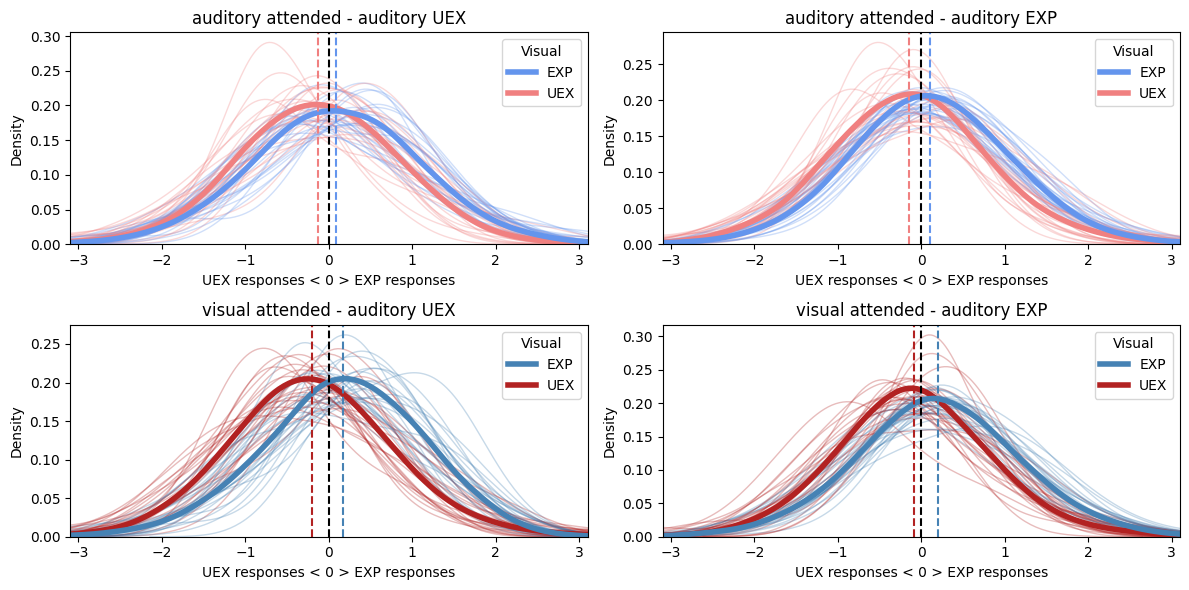

In [11]:
# Define a consistent color palette for EXP and UEX
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, modality in enumerate(["auditory", "visual"]):
    for j, a_pred in enumerate([0, 1]):
        plot_df = df[(df["modality"] == modality) & (df["a_pred"] == a_pred)]

        if modality == "visual":
            palette = {"EXP": "steelblue", "UEX": "firebrick"}
        else:
            palette = {"EXP": "cornflowerblue", "UEX": "lightcoral"}


        if a_pred == 1:
            pred_label = "EXP"
        else: 
            pred_label = "UEX"

        # Column for plotting legend
        plot_df["Visual"] = np.where(plot_df["signal_noise"] == "signal", "EXP", "UEX")
        
        # Plot individual KDE curves for each subject
        for subj in plot_df['subj'].unique():
            subj_data = plot_df[plot_df['subj'] == subj]
            sns.kdeplot(
                data=subj_data, 
                x="z_distance", 
                hue="Visual", 
                hue_order=["EXP", "UEX"],  # Fixed legend order
                palette=palette, 
                fill=False, 
                alpha=0.3,  # Make individual curves semi-transparent
                linewidth=1,  # Make individual lines thinner
                ax=axes[i, j],
                bw_adjust=2,  # Adjust bandwidth for smoother curves
                legend=False  # Disable legend for individual curves
            )

        # Add group-level KDE for comparison
        sns.kdeplot(
            data=plot_df, 
            x="z_distance", 
            hue="Visual", 
            hue_order=["EXP", "UEX"],  # Fixed legend order
            palette=palette, 
            fill=False, 
            ax=axes[i, j],
            bw_adjust=2,
            linewidth=4  # Make group-level lines thicker
        )

        # Calculate and add vertical lines for means
        signal_avg = plot_df[plot_df["signal_noise"] == "signal"]["z_distance"].mean()
        noise_avg = plot_df[plot_df["signal_noise"] == "noise"]["z_distance"].mean()
        axes[i, j].axvline(x=0, color="black", linestyle="--")
        axes[i, j].axvline(x=signal_avg, color=palette["EXP"], linestyle="--")
        axes[i, j].axvline(x=noise_avg, color=palette["UEX"], linestyle="--")
        axes[i, j].set_title(f"{modality} attended - auditory {pred_label}")
        axes[i, j].set_xlim([-3.1, 3.1])
        axes[i, j].set_xlabel("UEX responses < 0 > EXP responses")

# Adjust layout and show the plot
plt.tight_layout()



## Checking effects separating also by expected stimulus

In [12]:
df_exp = pd.read_csv(f"{DATA_PATH}/balanced_group_data.csv")

df_exp["expected_stim"] = np.where(
    df_exp["v_pred"] == 1, 
    df_exp["labels"], 
    np.where(df_exp["labels"] == 45, 135, 45)
)

# Instead of jointly considering CW and CCW trials based on their expectedness,
# we will be considering them as signal and noise (arbitrarily) in order to confirm that the shift in criterion towards the expected stimuli
# corresponds to an actual shift towards the specific expected stimulus. This way we also make sure that the shift in criterion is observed towards only one of the two stimuli

df_exp["hit"] = np.where(
    (df_exp["correct"] == 1) & (df_exp["labels"] == 45), 1, 0
)

df_exp["fa"] = np.where(
    (df_exp["correct"] == 0) & (df_exp["labels"] == 135), 1, 0
)

df_exp["CR"] = np.where(
    (df_exp["correct"] == 1) & (df_exp["labels"] == 135), 1, 0
)

df_exp["miss"] = np.where(
    (df_exp["correct"] == 0) & (df_exp["labels"] == 45), 1, 0

)

# Alternatively, code decision type in a single column
df_exp["decision_type"] = np.where(
    (df_exp["correct"] == 1) & (df_exp["labels"] == 45), "hit",
    np.where(
        (df_exp["correct"] == 0) & (df_exp["labels"] == 135), "fa",
        np.where(
            (df_exp["correct"] == 1) & (df_exp["labels"] == 135), "CR",
            np.where(
                (df_exp["correct"] == 0) & (df_exp["labels"] == 45), "miss",
                "error"
            )
        )
    )
)

# New column for signal and noise trials
df_exp["signal_noise"] = np.where(
    (df_exp["decision_type"] == "hit") | (df_exp["decision_type"] == "miss"), "signal",
    np.where(
        (df_exp["decision_type"] == "fa") | (df_exp["decision_type"] == "CR"), "noise",
        "error"
    )
)

df_CW = df_exp[df_exp["expected_stim"] == 45]
df_CCW = df_exp[df_exp["expected_stim"] == 135]

### Global test

In [13]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
sdt_df_CW =compute_dprime(df_CW, "signal_noise", ["modality"])
sdt_df_CCW =compute_dprime(df_CCW, "signal_noise", ["modality"])

sdt_df_CW["expected_stim"] = 45
sdt_df_CCW["expected_stim"] = 135

dat_simple = pd.concat([sdt_df_CW, sdt_df_CCW])

dprime_results = AnovaRM(dat_simple, "d_prime", "subj", within=["modality", "expected_stim"]).fit()
criterion_results = AnovaRM(dat_simple, "criterion", "subj", within=["modality", "expected_stim"]).fit()


,F Value,Num DF,Den DF,Pr > F
modality,3.7706,1.0000,24.0000,0.0640
expected_stim,2.6697,1.0000,24.0000,0.1153
modality:expected_stim,0.0986,1.0000,24.0000,0.7562


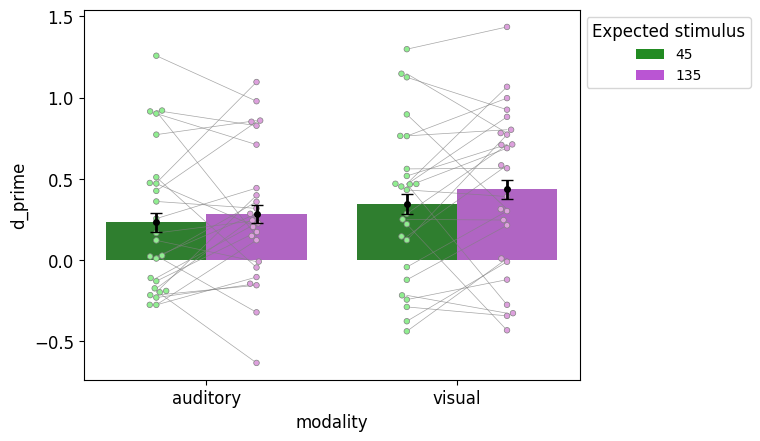

In [14]:
palette1 = ["forestgreen", "mediumorchid"]
palette2 = ["lightgreen", "plum"]
barplot_morey(dat_simple, "modality", "d_prime", "expected_stim", "Expected stimulus", palette1, palette2, barplot_plot=True, swarmplot_plot=True, within_lines=True)
dprime_results.summary()

,F Value,Num DF,Den DF,Pr > F
modality,0.9463,1.0000,24.0000,0.3404
expected_stim,0.0041,1.0000,24.0000,0.9497
modality:expected_stim,2.7382,1.0000,24.0000,0.1110


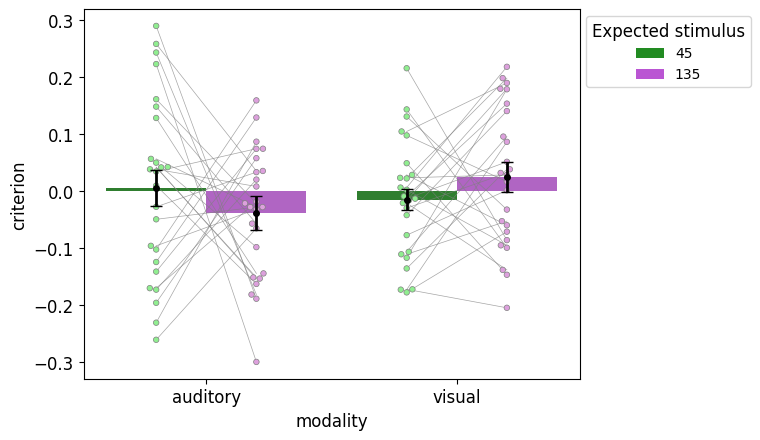

In [15]:
barplot_morey(dat_simple, "modality", "criterion", "expected_stim", "Expected stimulus", palette1, palette2, barplot_plot=True, swarmplot_plot=True, within_lines=True)
criterion_results.summary()

### By modality and auditory prediction

In [16]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
dat_CW =compute_dprime(df_CW, "signal_noise", ["modality", "a_pred"])
dat_CW["expected_stim"] = "CW"
dat_CCW =compute_dprime(df_CCW, "signal_noise", ["modality", "a_pred"])
dat_CCW["expected_stim"] = "CCW"
dat = pd.concat([dat_CW, dat_CCW])

C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

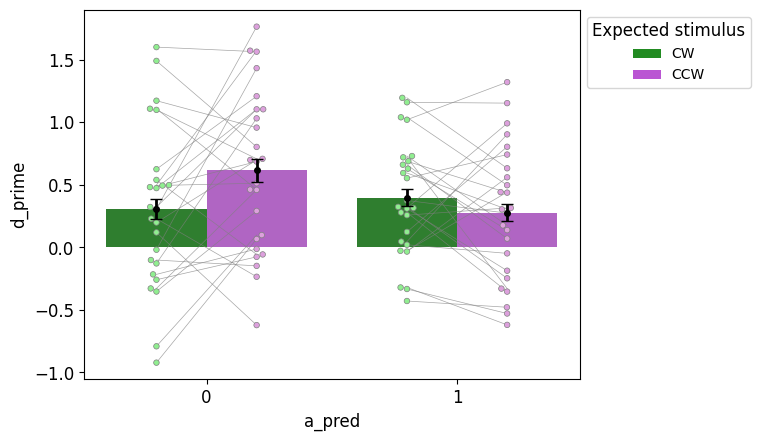

In [17]:
plot_df = dat[(dat["modality"] == "visual")]
barplot_morey(plot_df, "a_pred", "d_prime", "expected_stim", "Expected stimulus", palette1, palette2, barplot_plot=True, swarmplot_plot=True, within_lines=True)

C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

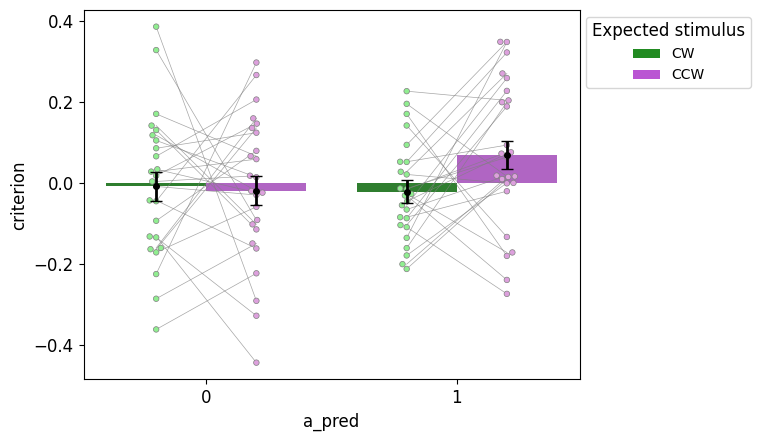

In [18]:
plot_df = dat[(dat["modality"] == "visual")]
barplot_morey(plot_df, "a_pred", "criterion", "expected_stim", "Expected stimulus", palette1, palette2, barplot_plot=True, swarmplot_plot=True, within_lines=True)

C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

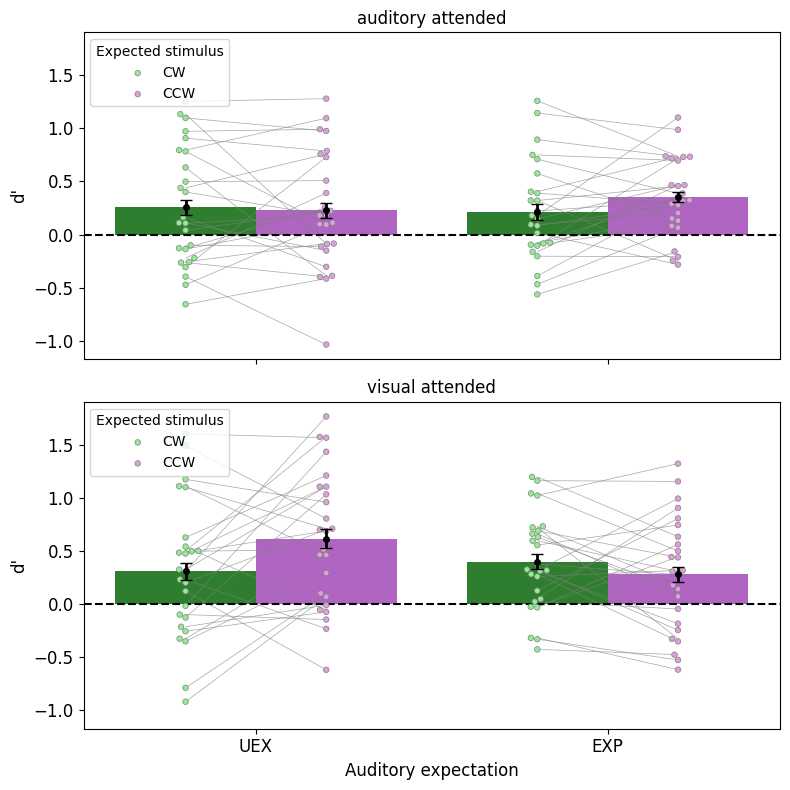

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=True, sharex=True)
for i, modality in enumerate(["auditory", "visual"]):
    plot_df = dat[(dat["modality"] == modality)]

    barplot_morey(plot_df, "a_pred", "d_prime", "expected_stim", "Expected stimulus", palette1, palette2, barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[i])
    
    # Format the title with F and p values
    axes[i].set_title(f"{modality} attended")

    axes[i].axhline(y=0, color="black", linestyle="--")
    axes[i].set_xlabel("Auditory expectation")
    axes[i].set_ylabel("d'")
    axes[i].set_xticklabels(["UEX", "EXP"])
    axes[i].legend(title="Expected stimulus", loc="upper left", labels=["CW", "CCW"])

# Adjust layout and show the plot
plt.tight_layout()


In [20]:
pg.rm_anova(data=dat[dat["modality"]=="visual"], dv="d_prime", within=["a_pred", "expected_stim"], subject="subj")

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,a_pred,0.378427,1,24,0.378427,3.260845,0.083512,0.083512,0.011707,1.0
1,expected_stim,0.230457,1,24,0.230457,1.512019,0.230750,0.230750,0.007162,1.0
2,a_pred * expected_stim,1.137632,1,24,1.137632,5.656912,0.025693,0.025693,0.034386,1.0


In [21]:
pg.pairwise_tests(data=dat[dat["modality"]=="visual"], dv="d_prime", within=["a_pred", "expected_stim"], subject="subj", padjust="fdr_bh")

,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,a_pred,-,0,1,True,True,1.805781,24.0,two-sided,0.083512,NaN,NaN,0.86,0.244964
1,expected_stim,-,CCW,CW,True,True,1.229642,24.0,two-sided,0.230750,NaN,NaN,0.414,0.187705
2,a_pred * expected_stim,0,CCW,CW,True,True,2.276652,24.0,two-sided,0.032014,0.064027,fdr_bh,1.829,0.472605
3,a_pred * expected_stim,1,CCW,CW,True,True,-1.183738,24.0,two-sided,0.248109,0.248109,fdr_bh,0.394,-0.230703


C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

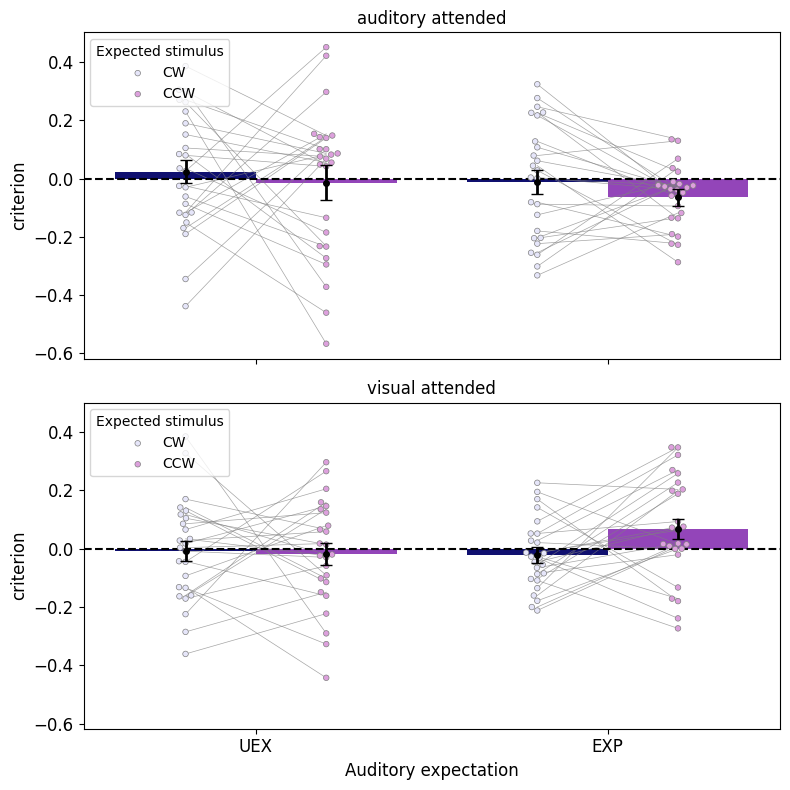

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=True, sharex=True)
for i, modality in enumerate(["auditory", "visual"]):
    plot_df = dat[(dat["modality"] == modality)]

    
    barplot_morey(plot_df, "a_pred", "criterion", "expected_stim", "Expected stimulus", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[i])


    
    # Format the title with F and p values
    axes[i].set_title(f"{modality} attended")

    axes[i].axhline(y=0, color="black", linestyle="--")
    axes[i].set_xlabel("Auditory expectation")
    axes[i].set_ylabel("criterion")
    axes[i].set_xticklabels(["UEX", "EXP"])
    axes[i].legend(title="Expected stimulus", loc="upper left", labels=["CW", "CCW"])

# Adjust layout and show the plot
plt.tight_layout()


In [24]:
pg.rm_anova(data=dat[dat["modality"]=="visual"], dv="criterion", within=["a_pred", "expected_stim"], subject="subj")

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,a_pred,0.033841,1,24,0.033841,1.173824,0.289382,0.289382,0.012458,1.0
1,expected_stim,0.039872,1,24,0.039872,1.402537,0.247896,0.247896,0.014646,1.0
2,a_pred * expected_stim,0.062861,1,24,0.062861,2.189493,0.151963,0.151963,0.022897,1.0


In [25]:
pg.pairwise_tests(data=dat[dat["modality"]=="visual"], dv="criterion", within=["a_pred", "expected_stim"], subject="subj", padjust="fdr_bh")

,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,a_pred,-,0,1,True,True,-1.083432,24.0,two-sided,0.289382,NaN,NaN,0.357,-0.309876
1,expected_stim,-,CCW,CW,True,True,1.184287,24.0,two-sided,0.247896,NaN,NaN,0.394,0.337600
2,a_pred * expected_stim,0,CCW,CW,True,True,-0.196710,24.0,two-sided,0.845711,0.845711,fdr_bh,0.215,-0.055743
3,a_pred * expected_stim,1,CCW,CW,True,True,2.078541,24.0,two-sided,0.048520,0.097040,fdr_bh,1.312,0.579679
